In [1]:
# Celda 1: Versión alternativa con más configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración detallada de visualización
plt.style.use('default')
sns.set_theme(style="whitegrid",  # Estilo con grid
              palette="deep",     # Paleta de colores
              font_scale=1.1)     # Tamaño de fuente

# Configuración adicional de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
# Celda 2: Carga inicial de datos
data_path = Path("../data/rollingsales_manhattan.xls")
df = pd.read_excel(data_path, skiprows=4)

In [3]:
# Celda 3: Renombrado de columnas y conversión inicial de tipos
# Diccionario para renombrar columnas
column_names = {
    'BOROUGH': 'borough',
    'NEIGHBORHOOD': 'neighborhood',
    'BUILDING CLASS CATEGORY': 'building_class_category',
    'TAX CLASS AT PRESENT': 'tax_class_present',
    'BLOCK': 'block',
    'LOT': 'lot',
    'EASE-MENT': 'easement',
    'BUILDING CLASS AT PRESENT': 'building_class_present',
    'ADDRESS': 'address',
    'APART\nMENT\nNUMBER': 'apartment_number',
    'ZIP CODE': 'zip_code',
    'RESIDENTIAL UNITS': 'residential_units',
    'COMMERCIAL UNITS': 'commercial_units',
    'TOTAL UNITS': 'total_units',
    'LAND SQUARE FEET': 'land_sqft',
    'GROSS SQUARE FEET': 'gross_sqft',
    'YEAR BUILT': 'year_built',
    'TAX CLASS AT TIME OF SALE': 'tax_class_sale',
    'BUILDING CLASS AT TIME OF SALE': 'building_class_sale',
    'SALE\nPRICE': 'sale_price',
    'SALE DATE': 'sale_date'
}

# Renombrar columnas
df = df.rename(columns=column_names)

# Convertir tipos de datos
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Columnas numéricas identificadas
numeric_columns = ['block', 'lot', 'residential_units', 'commercial_units', 
                  'total_units', 'land_sqft', 'gross_sqft', 'year_built', 
                  'sale_price']

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar duplicados
df_clean = df.drop_duplicates()

In [4]:
# Celda 4: Funciones de limpieza
def clean_sale_price(df):
    """Limpia los precios de venta eliminando valores no válidos y outliers."""
    df = df[df['sale_price'] > 0]
    price_threshold = df['sale_price'].quantile(0.999)
    df = df[df['sale_price'] <= price_threshold]
    return df

def clean_square_feet(df):
    """Limpia los datos de superficie convirtiendo 0s a NaN."""
    df.loc[df['land_sqft'] == 0, 'land_sqft'] = np.nan
    df.loc[df['gross_sqft'] == 0, 'gross_sqft'] = np.nan
    return df

def clean_year_built(df):
    """Limpia el año de construcción eliminando valores no válidos."""
    df.loc[df['year_built'] == 0, 'year_built'] = np.nan
    df = df[df['year_built'].isna() | (df['year_built'] >= 1800)]
    return df

In [5]:
# Celda 5: Aplicación de limpieza
df_clean = clean_sale_price(df_clean)
df_clean = clean_square_feet(df_clean)
df_clean = clean_year_built(df_clean)

In [6]:
# Celda 6: Análisis exploratorio inicial
print("Estadísticas post-limpieza:")
print("\nPrecios de venta:")
print(df_clean['sale_price'].describe())

print("\nSuperficie construida:")
print(df_clean['gross_sqft'].describe())

print("\nAño de construcción:")
print(df_clean['year_built'].describe())

# Análisis por vecindario
neighborhood_stats = df_clean.groupby('neighborhood').agg({
    'sale_price': ['count', 'mean', 'median'],
    'gross_sqft': 'median',
    'year_built': 'median'
}).round(2)

print("\nEstadísticas por vecindario (top 10 por número de ventas):")
print(neighborhood_stats.sort_values(('sale_price', 'count'), ascending=False).head(10))

Estadísticas post-limpieza:

Precios de venta:
count       18911.000
mean      2184042.659
std       8589498.383
min             1.000
25%        415000.000
50%        779000.000
75%       1695000.000
max     250000000.000
Name: sale_price, dtype: float64

Superficie construida:
count     2225.000
mean     52470.395
std      63848.983
min        999.000
25%       5600.000
50%      16790.000
75%     112850.000
max     662729.000
Name: gross_sqft, dtype: float64

Año de construcción:
count   15707.000
mean     1950.279
std        35.172
min      1800.000
25%      1922.000
50%      1950.000
75%      1978.000
max      2013.000
Name: year_built, dtype: float64

Estadísticas por vecindario (top 10 por número de ventas):
                          sale_price                         gross_sqft  \
                               count        mean      median     median   
neighborhood                                                              
MIDTOWN WEST                    2719 1379271.100   

C:\Users\PC\AppData\Local\Temp\ipykernel_7760\4204512313.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45)


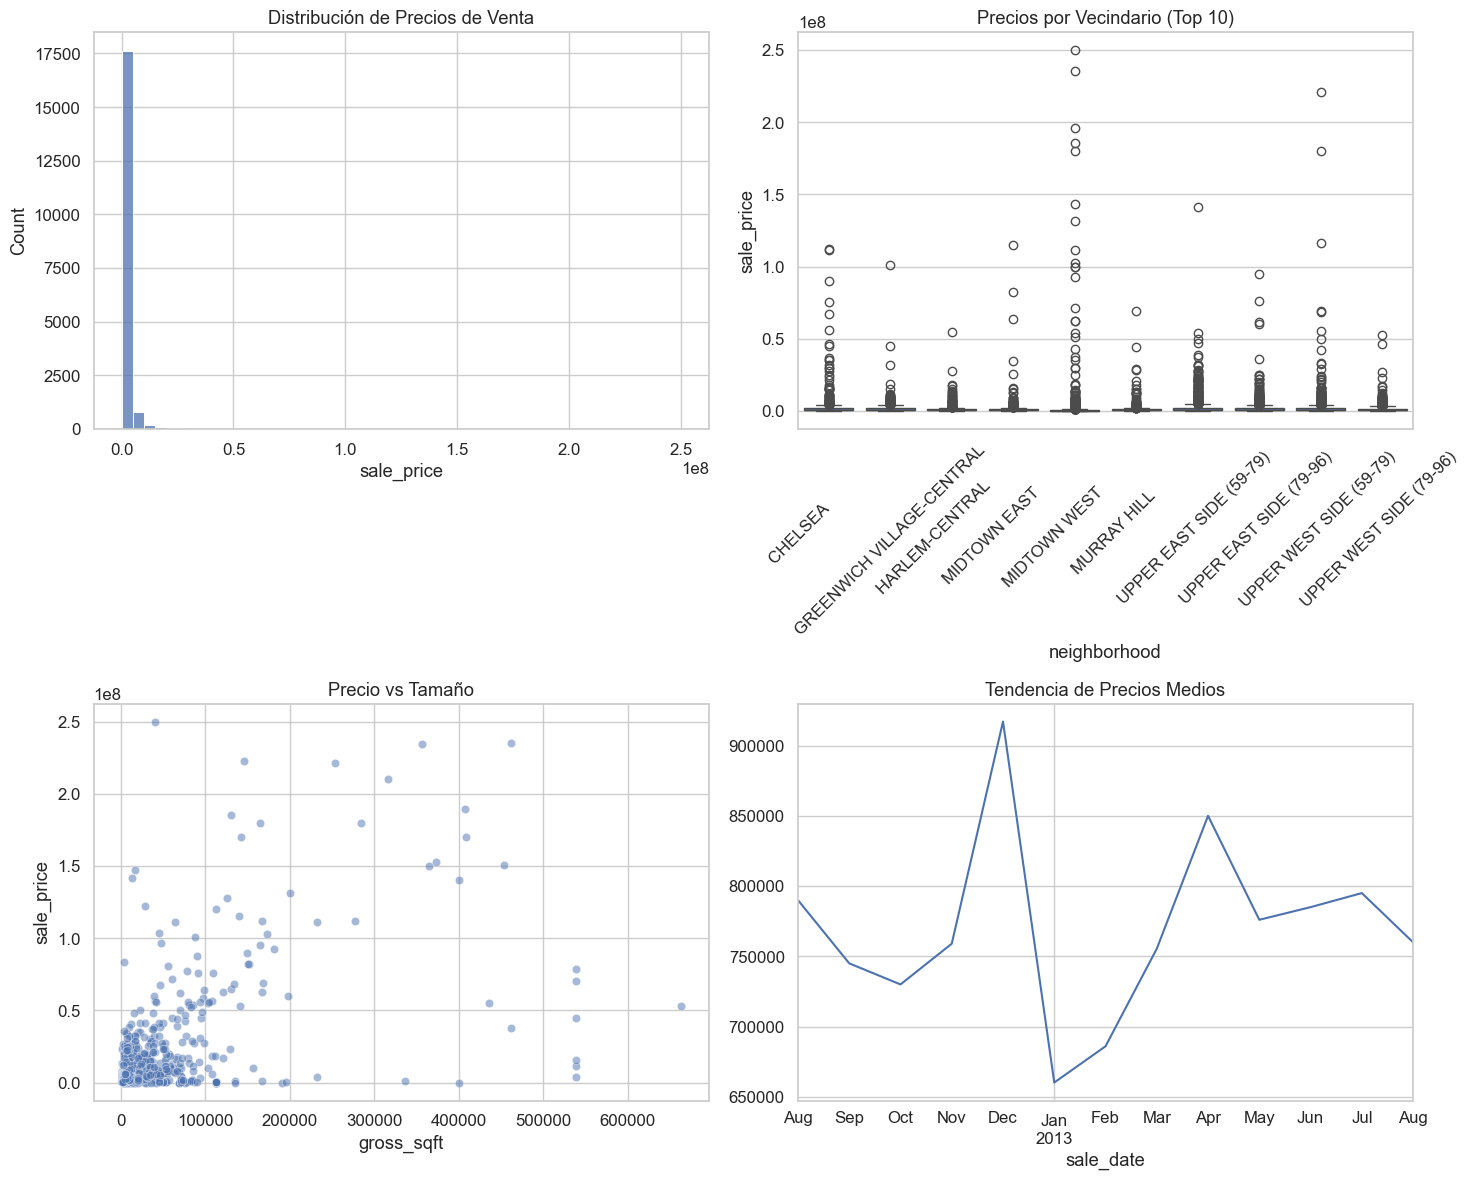

In [8]:
# Celda 7: Visualizaciones básicas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribución de precios
sns.histplot(data=df_clean, x='sale_price', bins=50, ax=axes[0,0])
axes[0,0].set_title('Distribución de Precios de Venta')

# Box plot de precios por vecindario (top 10)
top_neighborhoods = df_clean['neighborhood'].value_counts().head(10).index
sns.boxplot(data=df_clean[df_clean['neighborhood'].isin(top_neighborhoods)], 
            x='neighborhood', y='sale_price', ax=axes[0,1])
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45)
axes[0,1].set_title('Precios por Vecindario (Top 10)')

# Scatter plot: precio vs tamaño
sns.scatterplot(data=df_clean, x='gross_sqft', y='sale_price', alpha=0.5, ax=axes[1,0])
axes[1,0].set_title('Precio vs Tamaño')

# Tendencia temporal de precios
df_clean.groupby(df_clean['sale_date'].dt.to_period('M'))['sale_price'].median().plot(ax=axes[1,1])
axes[1,1].set_title('Tendencia de Precios Medios')

plt.tight_layout()
plt.show()

In [9]:
# Celda: Análisis de Calidad de Datos y Segmentación

# 1. Análisis de datos faltantes por tipo de propiedad
missing_analysis = df_clean.groupby('building_class_category').agg({
    'gross_sqft': lambda x: x.isna().sum(),
    'sale_price': 'count'
}).assign(
    pct_missing_sqft=lambda x: (x['gross_sqft'] / x['sale_price'] * 100).round(2)
).sort_values('sale_price', ascending=False)

print("Análisis de datos faltantes por tipo de propiedad:")
print(missing_analysis)

# 2. Segmentación Residencial vs Comercial
def classify_property_type(building_class):
    if 'RESIDENTIAL' in building_class.upper() or 'FAMILY' in building_class.upper():
        return 'Residencial'
    elif 'COMMERCIAL' in building_class.upper() or 'OFFICE' in building_class.upper():
        return 'Comercial'
    else:
        return 'Otro'

df_clean['property_type'] = df_clean['building_class_category'].apply(classify_property_type)

# 3. Análisis de outliers extremos
price_threshold_99 = df_clean['sale_price'].quantile(0.99)
extreme_sales = df_clean[df_clean['sale_price'] > price_threshold_99].sort_values('sale_price', ascending=False)

print("\nTop 10 ventas más altas:")
print(extreme_sales[['address', 'neighborhood', 'sale_price', 'property_type', 'building_class_category']].head(10))

# 4. Análisis temporal con segmentación
monthly_stats = df_clean.groupby([
    df_clean['sale_date'].dt.to_period('M'),
    'property_type'
]).agg({
    'sale_price': ['median', 'count']
}).unstack()

print("\nEstadísticas mensuales por tipo de propiedad:")
print(monthly_stats)

Análisis de datos faltantes por tipo de propiedad:
                                              gross_sqft  sale_price  \
building_class_category                                                
10  COOPS - ELEVATOR APARTMENTS                     6887        6895   
13  CONDOS - ELEVATOR APARTMENTS                    5922        5922   
                                                    1143        1143   
17  CONDOPS                                         1004        1008   
09  COOPS - WALKUP APARTMENTS                        723         729   
25  LUXURY HOTELS                                      0         710   
07  RENTALS - WALKUP APARTMENTS                        0         581   
28  COMMERCIAL CONDOS                                486         486   
15  CONDOS - 2-10 UNIT RESIDENTIAL                   297         297   
08  RENTALS - ELEVATOR APARTMENTS                      0         152   
01  ONE FAMILY HOMES                                   0         128   
02  TWO FAMIL

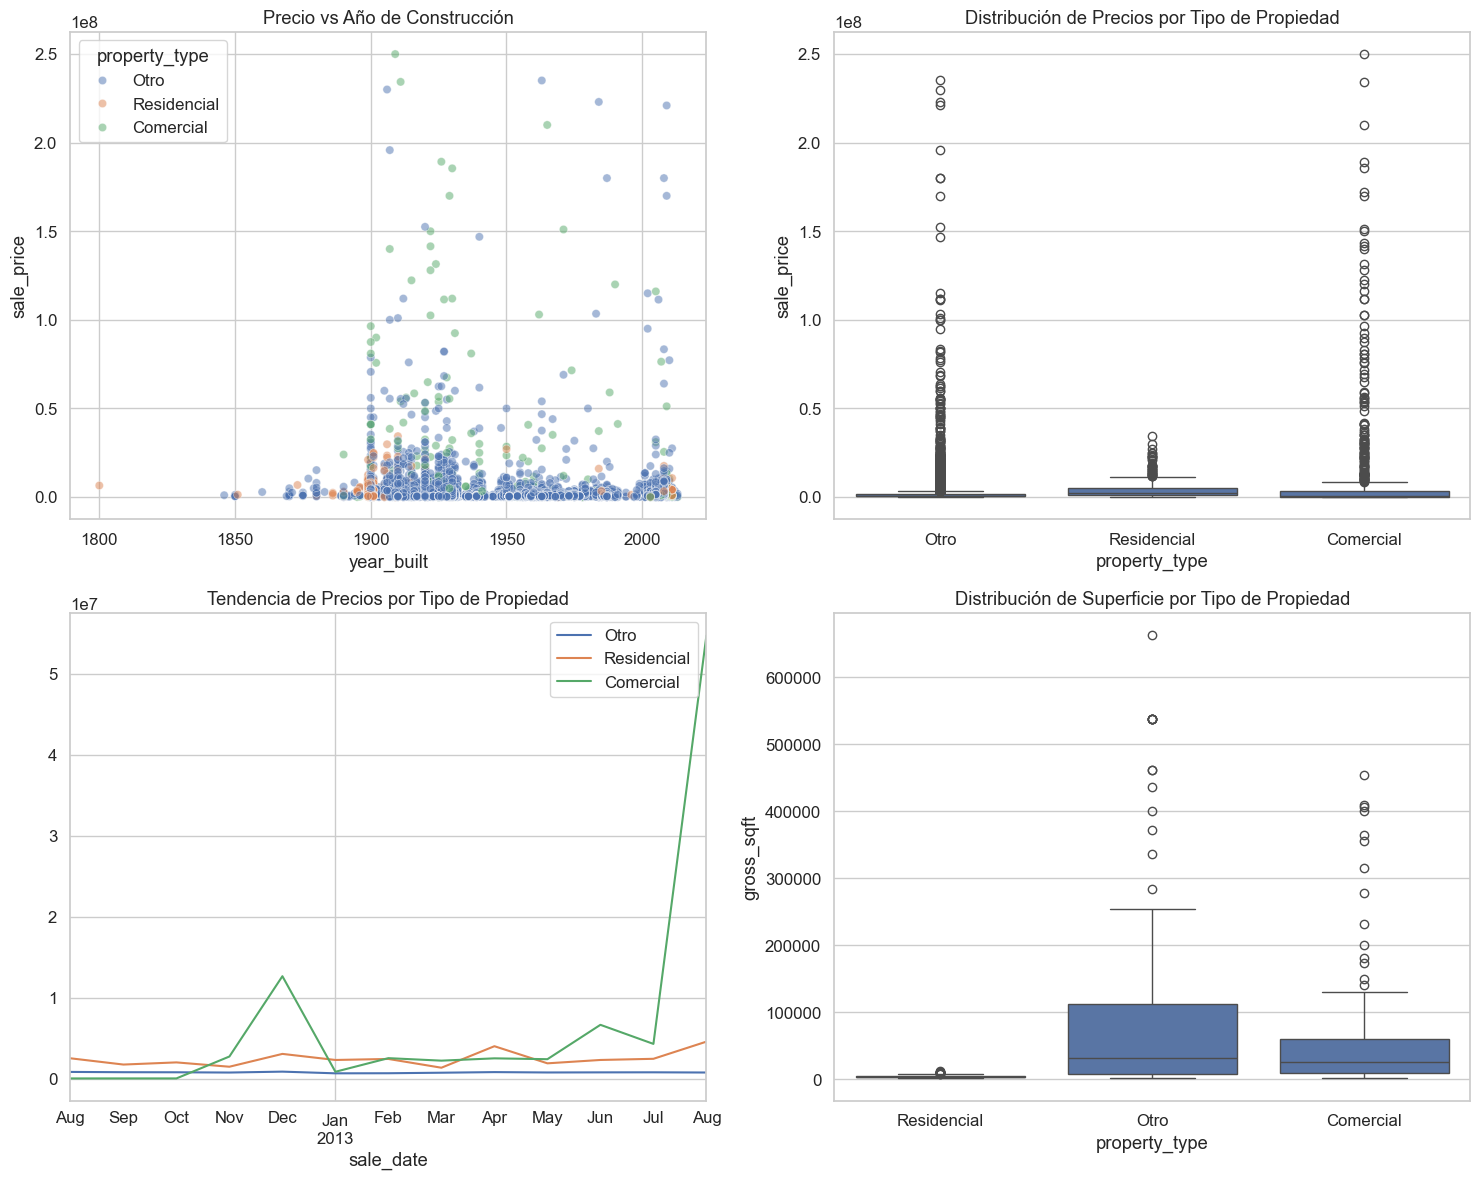

In [10]:
# Celda: Visualizaciones Mejoradas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Precio vs Año de Construcción
sns.scatterplot(
    data=df_clean[df_clean['year_built'] >= 1800],
    x='year_built',
    y='sale_price',
    hue='property_type',
    alpha=0.5,
    ax=axes[0,0]
)
axes[0,0].set_title('Precio vs Año de Construcción')

# 2. Distribución de Precios por Tipo de Propiedad
sns.boxplot(
    data=df_clean,
    x='property_type',
    y='sale_price',
    ax=axes[0,1]
)
axes[0,1].set_title('Distribución de Precios por Tipo de Propiedad')

# 3. Tendencia Temporal por Tipo de Propiedad
for prop_type in df_clean['property_type'].unique():
    mask = df_clean['property_type'] == prop_type
    df_clean[mask].groupby(df_clean[mask]['sale_date'].dt.to_period('M'))['sale_price'].median().plot(
        ax=axes[1,0],
        label=prop_type
    )
axes[1,0].set_title('Tendencia de Precios por Tipo de Propiedad')
axes[1,0].legend()

# 4. Distribución de Superficie por Tipo de Propiedad
sns.boxplot(
    data=df_clean[df_clean['gross_sqft'].notna()],
    x='property_type',
    y='gross_sqft',
    ax=axes[1,1]
)
axes[1,1].set_title('Distribución de Superficie por Tipo de Propiedad')

plt.tight_layout()
plt.show()

In [11]:
# Celda: Resumen Ejecutivo Mejorado

print("""
RESUMEN EJECUTIVO - ANÁLISIS MERCADO INMOBILIARIO MANHATTAN

1. CALIDAD DE DATOS:
- Solo {:.1f}% de las propiedades tienen datos de superficie registrados
- La falta de datos es más pronunciada en propiedades residenciales
- Recomendación: Mejorar captura de datos, especialmente en propiedades residenciales

2. SEGMENTACIÓN DE MERCADO:
- Propiedades Residenciales: {:.1f}% del total
- Propiedades Comerciales: {:.1f}% del total
- Precio mediano residencial: ${:,.2f}
- Precio mediano comercial: ${:,.2f}

3. TENDENCIAS TEMPORALES:
- Peak diciembre 2012: posible efecto de cierre fiscal
- Caída enero 2013: potencial impacto de cambios regulatorios
- Recuperación gradual durante 2013

4. OUTLIERS Y CASOS ESPECIALES:
- {:.0f} propiedades con valores > ${:,.2f} (percentil 99)
- Máximo de ${:,.2f} requiere verificación
- Mayoría de outliers son edificios comerciales completos

5. RECOMENDACIONES:
- Implementar sistema robusto de captura de datos de superficie
- Desarrollar análisis geoespacial para identificar clusters de valor
- Segmentar análisis por tipo de propiedad para mejor precisión
""".format(
    len(df_clean[df_clean['gross_sqft'].notna()]) / len(df_clean) * 100,
    len(df_clean[df_clean['property_type'] == 'Residencial']) / len(df_clean) * 100,
    len(df_clean[df_clean['property_type'] == 'Comercial']) / len(df_clean) * 100,
    df_clean[df_clean['property_type'] == 'Residencial']['sale_price'].median(),
    df_clean[df_clean['property_type'] == 'Comercial']['sale_price'].median(),
    len(extreme_sales),
    price_threshold_99,
    df_clean['sale_price'].max()
))


RESUMEN EJECUTIVO - ANÁLISIS MERCADO INMOBILIARIO MANHATTAN

1. CALIDAD DE DATOS:
- Solo 11.8% de las propiedades tienen datos de superficie registrados
- La falta de datos es más pronunciada en propiedades residenciales
- Recomendación: Mejorar captura de datos, especialmente en propiedades residenciales

2. SEGMENTACIÓN DE MERCADO:
- Propiedades Residenciales: 3.1% del total
- Propiedades Comerciales: 3.8% del total
- Precio mediano residencial: $2,300,000.00
- Precio mediano comercial: $359,500.00

3. TENDENCIAS TEMPORALES:
- Peak diciembre 2012: posible efecto de cierre fiscal
- Caída enero 2013: potencial impacto de cambios regulatorios
- Recuperación gradual durante 2013

4. OUTLIERS Y CASOS ESPECIALES:
- 187 propiedades con valores > $23,000,000.00 (percentil 99)
- Máximo de $250,000,000.00 requiere verificación
- Mayoría de outliers son edificios comerciales completos

5. RECOMENDACIONES:
- Implementar sistema robusto de captura de datos de superficie
- Desarrollar análisis ge